In [3]:
# This cell contains all the necessary imports for the entire project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

In [4]:
# Load the dataset
orders = pd.read_csv("dataset/raw/olist_orders_dataset.csv")
order_items = pd.read_csv("dataset/raw/olist_order_items_dataset.csv")
customers = pd.read_csv("dataset/raw/olist_customers_dataset.csv")
reviews = pd.read_csv("dataset/raw/olist_order_reviews_dataset.csv")

In [12]:
df = pd.read_csv('dataset/processed/eda_df.csv')

###  Train-Test Split

In [13]:
# Create target variable
df["delivered_late"] = (df["order_delivered_customer_date"] > df["order_estimated_delivery_date"]).astype(int)
print(df[["order_estimated_delivery_date", "order_delivered_customer_date", "delivered_late"]].head())
print("Missing values in target:", df["delivered_late"].isna().sum())

  order_estimated_delivery_date order_delivered_customer_date  delivered_late
0                    2017-10-18           2017-10-10 21:25:13               0
1                    2018-08-13           2018-08-07 15:27:45               0
2                    2018-09-04           2018-08-17 18:06:29               0
3                    2017-12-15           2017-12-02 00:28:42               0
4                    2018-02-26           2018-02-16 18:17:02               0
Missing values in target: 0


In [14]:
# Separate features and target
X = df.drop(["delivered_late", "order_id", "customer_id", 
             "order_delivered_customer_date", "order_estimated_delivery_date"], axis=1,errors='ignore')
y = df["delivered_late"]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      
    random_state=42,     
    stratify=y           
)

# Check shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (79063, 9)
X_test : (19766, 9)


### 2. Data Preprocessing Pipeline

- Impute missing numeric values.

- Impute missing categorical values.

- Encode them to turn them into numbers.

- Outlier analysis

- Scale numeric features.

In [15]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoric_cols = X.select_dtypes(include=['object']).columns.tolist()

# Numeric pipeline 
# Fill missing values with median and scale data
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
# Fill missing values with most frequent and encode categories
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('onehot', OneHotEncoder(handle_unknown='ignore')) 
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categoric_cols)
    ]
)

X_preprocessed = preprocessor.fit_transform(X)

In [ ]:
df["delivered_late"].value_counts()

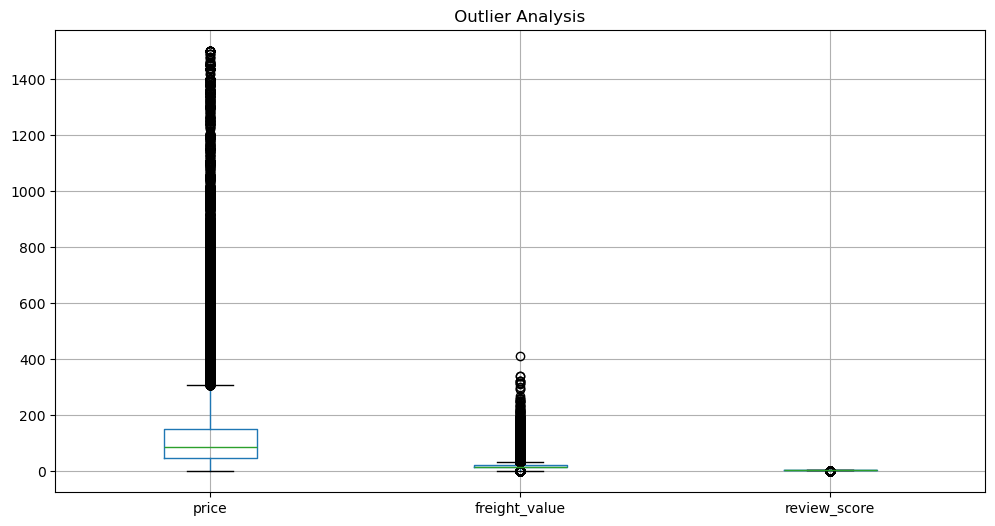

In [18]:
# Outlier Analysis for numeric columns
plt.figure(figsize=(12, 6))
df[numeric_cols].boxplot()
plt.title(" Outlier Analysis ")
plt.show()

### 3. Feature Selection

In [19]:
# Remove rows where price > 1500
df = df[df["price"] <= 1500]
print("Kalan satır sayısı / Remaining rows:", df.shape[0])

Kalan satır sayısı / Remaining rows: 98829


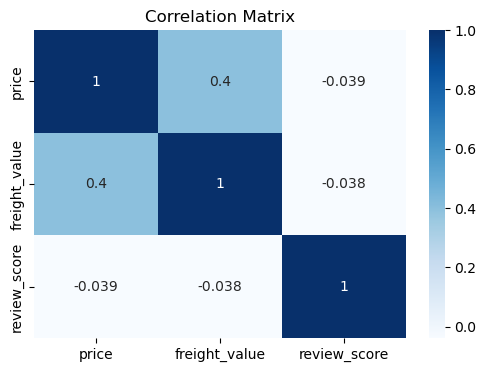

In [20]:
# Correlation Analysis
corr =df[numeric_cols].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

In [21]:
# Low Variance Filter
# Remove features that have little to no variance

selector = VarianceThreshold(threshold=0.01)  
selector.fit(X.select_dtypes(include=[np.number]))
low_var_cols = X.select_dtypes(include=[np.number]).columns[~selector.get_support()]
print("\n Low Variance Columns:")
print(low_var_cols)


 Low Variance Columns:
Index([], dtype='object')


In [22]:
# Feature Importance
# Use a simple Random Forest to measure feature importance

feature_names = preprocessor.get_feature_names_out()

rf = RandomForestClassifier(random_state=42)
rf.fit(X_preprocessed, y)


feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n Feature Importance (Top 10):")
print(feature_importance.head(10))


 Feature Importance (Top 10):
                                                  Feature  Importance
2                                       num__review_score    0.061983
1                                      num__freight_value    0.010167
0                                              num__price    0.008962
5                             cat__order_status_delivered    0.002192
272433                             cat__customer_state_RJ    0.002185
272440                             cat__customer_state_SP    0.002175
8                               cat__order_status_shipped    0.001223
272425                             cat__customer_state_MG    0.001107
254931  cat__order_delivered_carrier_date_2018-05-09 1...    0.000953
271767                     cat__customer_city_sao goncalo    0.000669


In [23]:
# Features after encoding
X_preprocessed.shape

(98829, 272442)